In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/WA_FnUseC_TelcoCustomerChurn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df["customerID"].duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [13]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [14]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [15]:
df["TotalCharges"].dtype

dtype('O')

In [16]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [17]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [18]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [19]:
df[df["TotalCharges"] == " "][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [20]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")

In [21]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [22]:
df["TotalCharges"].dtype

dtype('float64')

In [23]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [24]:
df[df["tenure"] == 0][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,0.0
753,0,20.25,0.0
936,0,80.85,0.0
1082,0,25.75,0.0
1340,0,56.05,0.0
3331,0,19.85,0.0
3826,0,25.35,0.0
4380,0,20.00,0.0
5218,0,19.70,0.0
6670,0,73.35,0.0


In [25]:
for column in df.select_dtypes(include="object").columns:
    print(f"\n--- {column} ---")
    print(df[column].unique())


--- customerID ---
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

--- gender ---
['Female' 'Male']

--- Partner ---
['Yes' 'No']

--- Dependents ---
['No' 'Yes']

--- PhoneService ---
['No' 'Yes']

--- MultipleLines ---
['No phone service' 'No' 'Yes']

--- InternetService ---
['DSL' 'Fiber optic' 'No']

--- OnlineSecurity ---
['No' 'Yes' 'No internet service']

--- OnlineBackup ---
['Yes' 'No' 'No internet service']

--- DeviceProtection ---
['No' 'Yes' 'No internet service']

--- TechSupport ---
['No' 'Yes' 'No internet service']

--- StreamingTV ---
['No' 'Yes' 'No internet service']

--- StreamingMovies ---
['No' 'Yes' 'No internet service']

--- Contract ---
['Month-to-month' 'One year' 'Two year']

--- PaperlessBilling ---
['Yes' 'No']

--- PaymentMethod ---
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

--- Churn ---
['No' 'Yes']


In [26]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [27]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


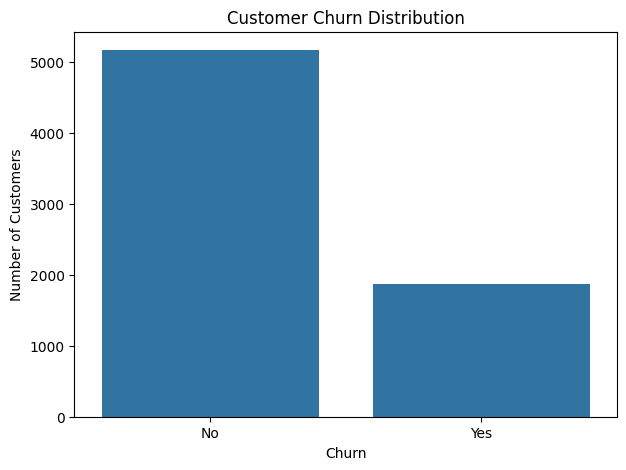

In [30]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

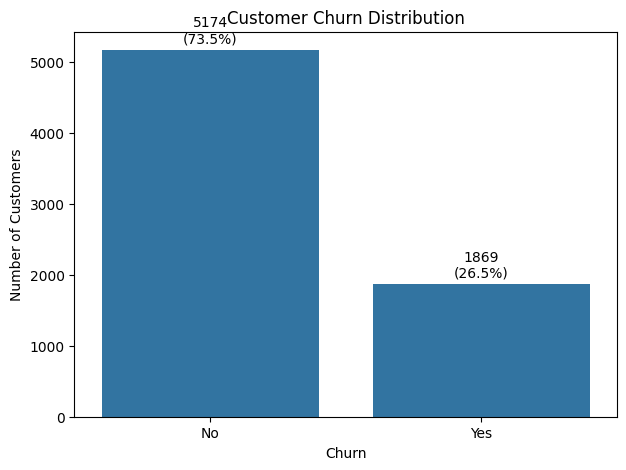

In [31]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    percentage = value / len(df) * 100
    ax.text(i, value + 100, f"{value}\n({percentage:.1f}%)", 
            ha="center")

plt.show()

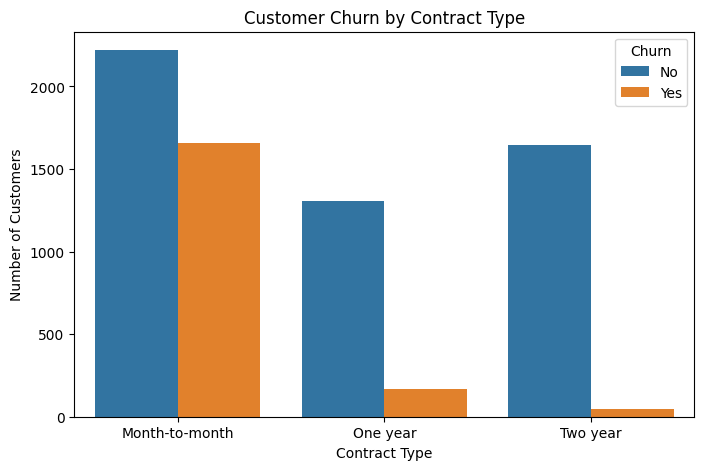

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [33]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


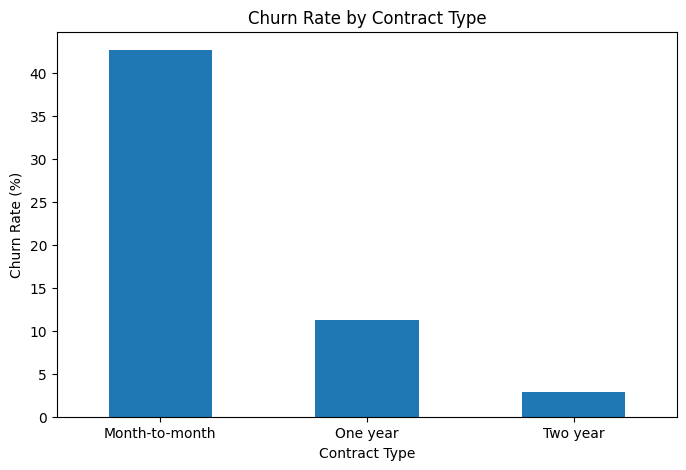

In [34]:
contract_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [35]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

In [36]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


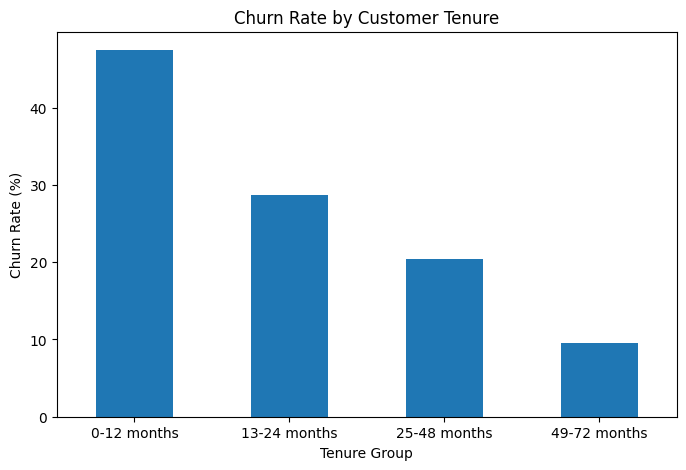

In [37]:
tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

<Axes: xlabel='Churn', ylabel='count'>

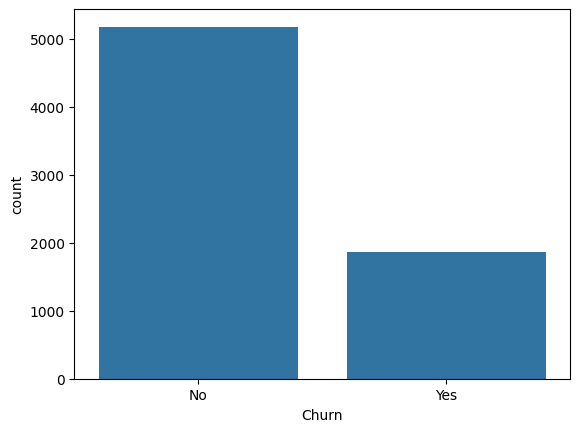

In [38]:
sns.countplot(data=df, x="Churn")

<Axes: xlabel='Contract', ylabel='count'>

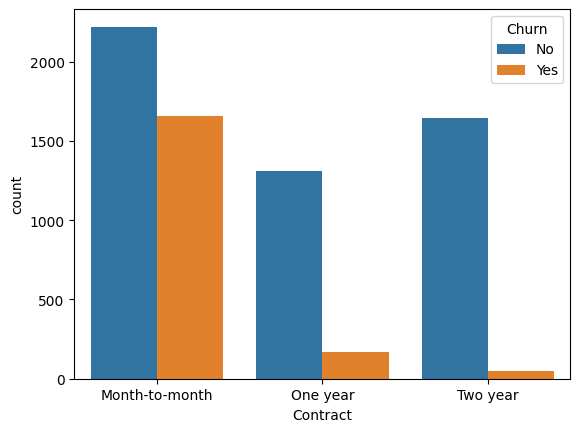

In [39]:
sns.countplot(data=df, x="Contract", hue="Churn")

In [40]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


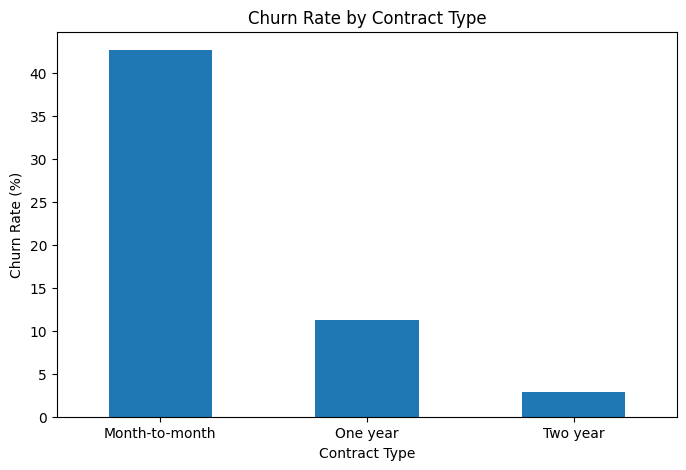

In [41]:
plt.figure(figsize=(8, 5))

contract_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [42]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


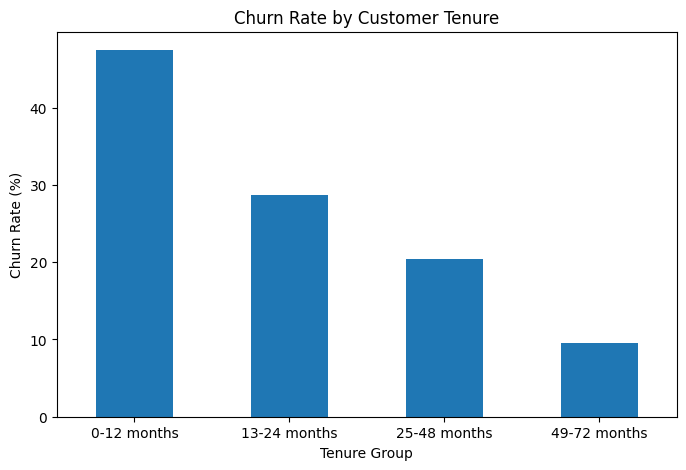

In [43]:
plt.figure(figsize=(8, 5))

tenure_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

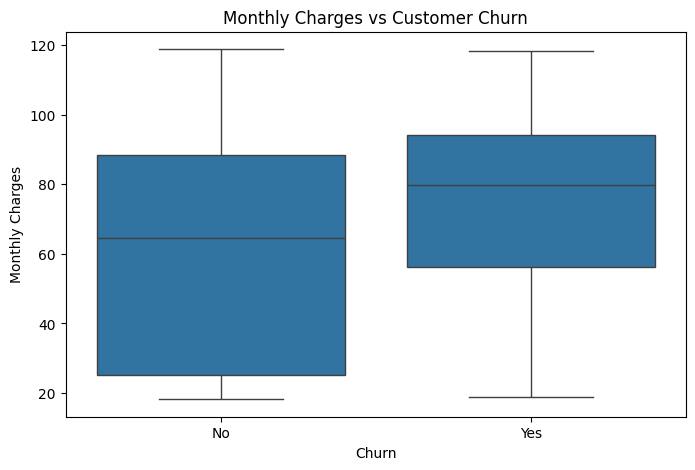

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [45]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


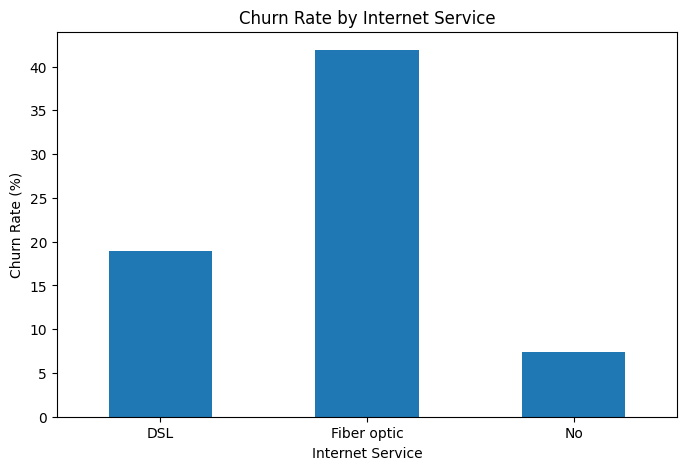

In [46]:
plt.figure(figsize=(8, 5))

internet_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [47]:
df_model = df.drop(columns=["customerID", "TenureGroup"])

In [48]:
df_model.shape

(7043, 20)

In [49]:
df_model["Churn"] = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [50]:
df_model["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [51]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

In [52]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [53]:
X.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [54]:
from sklearn.model_selection import train_test_split

In [57]:
X_train.shape
X_test.shape
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True))

print("\nTesting target:")
print(y_test.value_counts(normalize=True))

Training data: (5634, 19)
Testing data: (1409, 19)

Training target:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing target:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [58]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical features:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [60]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [62]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [63]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [64]:
y_pred = logistic_model.predict(X_test)

In [65]:
y_probability = logistic_model.predict_proba(X_test)[:, 1]

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [67]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probability))

Accuracy: 0.8055358410220014
Precision: 0.6572327044025157
Recall: 0.5588235294117647
F1 Score: 0.6040462427745664
ROC-AUC: 0.8421349040274871


In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [69]:
from sklearn.ensemble import RandomForestClassifier

In [70]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [71]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
rf_pred = random_forest_model.predict(X_test)

In [73]:
rf_probability = random_forest_model.predict_proba(X_test)[:, 1]

In [74]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_probability))

Accuracy: 0.7835344215755855
Precision: 0.6210526315789474
Recall: 0.4732620320855615
F1 Score: 0.5371775417298937
ROC-AUC: 0.8226898137384071


In [75]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [78]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
rf_pred = random_forest_model.predict(X_test)

In [80]:
rf_probability = random_forest_model.predict_proba(X_test)[:, 1]

In [81]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_probability))

Accuracy: 0.7835344215755855
Precision: 0.6210526315789474
Recall: 0.4732620320855615
F1 Score: 0.5371775417298937
ROC-AUC: 0.8226898137384071


In [82]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [83]:
from xgboost import XGBClassifier

In [84]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

In [85]:
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [86]:
xgb_pred = xgb_model.predict(X_test)

In [87]:
xgb_probability = xgb_model.predict_proba(X_test)[:, 1]

In [88]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probability))

Accuracy: 0.7984386089425124
Precision: 0.6490066225165563
Recall: 0.5240641711229946
F1 Score: 0.5798816568047337
ROC-AUC: 0.8418597742127154


In [89]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [91]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [165 209]]


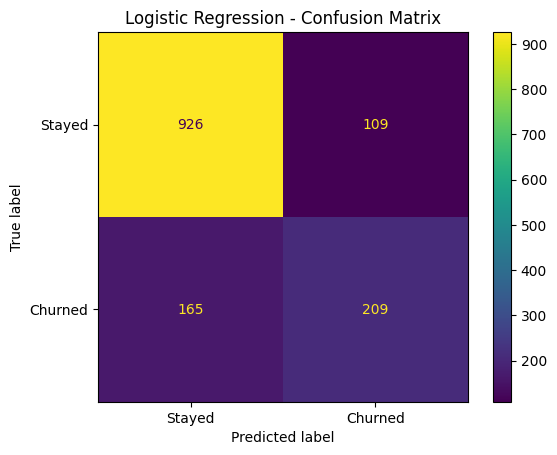

In [92]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [93]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 926
False Positives: 109
False Negatives: 165
True Positives  : 209


In [94]:
print("Total actual churners:", tp + fn)
print("Churners correctly identified:", tp)

Total actual churners: 374
Churners correctly identified: 209


In [95]:
balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

In [96]:
balanced_logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [97]:
balanced_pred = balanced_logistic_model.predict(X_test)

In [98]:
balanced_probability = balanced_logistic_model.predict_proba(X_test)[:, 1]

In [99]:
print("Accuracy:", accuracy_score(y_test, balanced_pred))
print("Precision:", precision_score(y_test, balanced_pred))
print("Recall:", recall_score(y_test, balanced_pred))
print("F1 Score:", f1_score(y_test, balanced_pred))
print("ROC-AUC:", roc_auc_score(y_test, balanced_probability))

Accuracy: 0.7381121362668559
Precision: 0.504302925989673
Recall: 0.7834224598930482
F1 Score: 0.6136125654450262
ROC-AUC: 0.8416388953473353


In [100]:
balanced_cm = confusion_matrix(y_test, balanced_pred)

print(balanced_cm)

[[747 288]
 [ 81 293]]


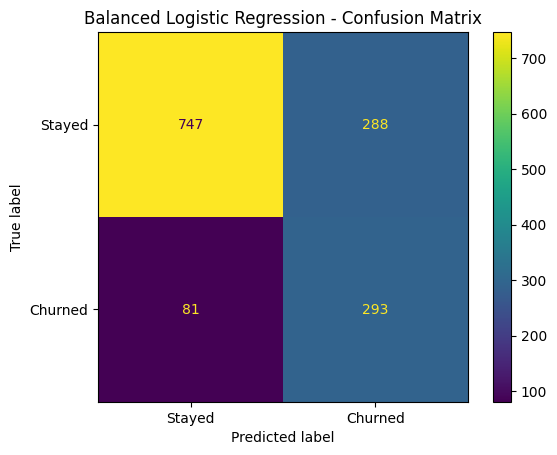

In [101]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=balanced_cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Balanced Logistic Regression - Confusion Matrix")
plt.show()

In [102]:
tn, fp, fn, tp = balanced_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 747
False Positives: 288
False Negatives: 81
True Positives  : 293


In [103]:
threshold = 0.40

threshold_pred = (balanced_probability >= threshold).astype(int)

In [104]:
print("Accuracy:", accuracy_score(y_test, threshold_pred))
print("Precision:", precision_score(y_test, threshold_pred))
print("Recall:", recall_score(y_test, threshold_pred))
print("F1 Score:", f1_score(y_test, threshold_pred))

Accuracy: 0.7012065294535131
Precision: 0.46618705035971225
Recall: 0.8663101604278075
F1 Score: 0.6061739943872778


In [105]:
threshold = 0.30

threshold_pred = (balanced_probability >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, threshold_pred))
print("Precision:", precision_score(y_test, threshold_pred))
print("Recall:", recall_score(y_test, threshold_pred))
print("F1 Score:", f1_score(y_test, threshold_pred))

Accuracy: 0.6543647977288858
Precision: 0.42998760842627015
Recall: 0.9278074866310161
F1 Score: 0.5876375952582558


In [106]:
feature_names = balanced_logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

In [107]:
coefficients = balanced_logistic_model.named_steps[
    "classifier"
].coef_[0]

In [108]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [109]:
feature_importance.sort_values(
    "Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
16,cat__InternetService_Fiber optic,0.707981
36,cat__Contract_Month-to-month,0.657713
3,num__TotalCharges,0.489698
35,cat__StreamingMovies_Yes,0.275392
32,cat__StreamingTV_Yes,0.262166
43,cat__PaymentMethod_Electronic check,0.240275
18,cat__OnlineSecurity_No,0.199030
27,cat__TechSupport_No,0.165519
14,cat__MultipleLines_Yes,0.132843
26,cat__DeviceProtection_Yes,0.074190


In [110]:
feature_importance.sort_values(
    "Coefficient",
    ascending=True
).head(15)

,Feature,Coefficient
1,num__tenure,-1.154434
38,cat__Contract_Two year,-0.775518
2,num__MonthlyCharges,-0.676114
15,cat__InternetService_DSL,-0.622465
25,cat__DeviceProtection_No internet service,-0.275403
22,cat__OnlineBackup_No internet service,-0.275403
19,cat__OnlineSecurity_No internet service,-0.275403
28,cat__TechSupport_No internet service,-0.275403
31,cat__StreamingTV_No internet service,-0.275403
17,cat__InternetService_No,-0.275403


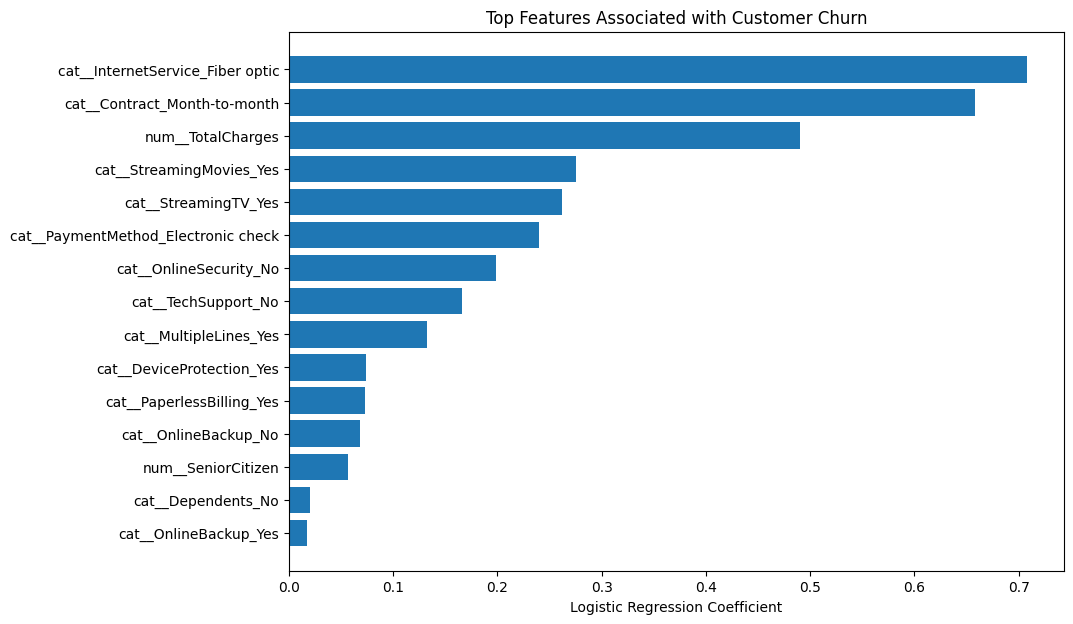

In [111]:
top_features = feature_importance.sort_values(
    "Coefficient"
).tail(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Features Associated with Customer Churn")
plt.xlabel("Logistic Regression Coefficient")

plt.show()

In [112]:
feature_importance.sort_values(
    "Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
16,cat__InternetService_Fiber optic,0.707981
36,cat__Contract_Month-to-month,0.657713
3,num__TotalCharges,0.489698
35,cat__StreamingMovies_Yes,0.275392
32,cat__StreamingTV_Yes,0.262166
43,cat__PaymentMethod_Electronic check,0.240275
18,cat__OnlineSecurity_No,0.199030
27,cat__TechSupport_No,0.165519
14,cat__MultipleLines_Yes,0.132843
26,cat__DeviceProtection_Yes,0.074190


In [113]:
feature_importance.sort_values(
    "Coefficient",
    ascending=True
).head(15)

,Feature,Coefficient
1,num__tenure,-1.154434
38,cat__Contract_Two year,-0.775518
2,num__MonthlyCharges,-0.676114
15,cat__InternetService_DSL,-0.622465
25,cat__DeviceProtection_No internet service,-0.275403
22,cat__OnlineBackup_No internet service,-0.275403
19,cat__OnlineSecurity_No internet service,-0.275403
28,cat__TechSupport_No internet service,-0.275403
31,cat__StreamingTV_No internet service,-0.275403
17,cat__InternetService_No,-0.275403


In [114]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [115]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [116]:
cv_results = cross_validate(
    balanced_logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

In [117]:
print("Cross-validation results:")
print("Accuracy :", cv_results["test_accuracy"].mean())
print("Precision:", cv_results["test_precision"].mean())
print("Recall   :", cv_results["test_recall"].mean())
print("F1 Score :", cv_results["test_f1"].mean())
print("ROC-AUC  :", cv_results["test_roc_auc"].mean())

Cross-validation results:
Accuracy : 0.7484929101766584
Precision: 0.5169334242384205
Recall   : 0.8013377926421403
F1 Score : 0.6282570726199064
ROC-AUC  : 0.8459527189246974


In [118]:
import joblib

In [119]:
joblib.dump(
    balanced_logistic_model,
    "../models/customer_churn_model.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: '../models/customer_churn_model.pkl'

In [120]:
import os

os.makedirs("../models", exist_ok=True)

In [121]:
joblib.dump(
    balanced_logistic_model,
    "../models/customer_churn_model.pkl"
)

['../models/customer_churn_model.pkl']

In [122]:
os.listdir("../models")

['customer_churn_model.pkl']

In [123]:
model_package = {
    "model": balanced_logistic_model,
    "threshold": 0.40
}

In [124]:
joblib.dump(
    model_package,
    "../models/customer_churn_model.pkl"
)

['../models/customer_churn_model.pkl']

In [125]:
loaded_package = joblib.load(
    "../models/customer_churn_model.pkl"
)

In [126]:
loaded_model = loaded_package["model"]
loaded_threshold = loaded_package["threshold"]

print("Model loaded successfully!")
print("Threshold:", loaded_threshold)

Model loaded successfully!
Threshold: 0.4
